<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# Smart-Turn — train (SpecAugment)

Variant of `02_a_train_baseline.ipynb` that turns on SpecAugment —
random time + frequency masking on the mel features during training.
Acts as cheap data augmentation + regularizer; with ~1k clips it's the
highest-leverage single change before getting more data.

Everything else (model, threshold sweep, F1-driven early stop, PR
curve) matches the baseline — only the dataset's `augment` callable
and `RUN_NAME` change. Compare against the baseline (and any other
`02_<letter>_*` variants) in `03_compare.ipynb`.

## Configure

`RUN_NAME` is the subdir under `checkpoints/<dataset>/` where this
variant's HF checkpoint + `threshold.json` lands. Keep it stable per
variant so `03_compare.ipynb` (and the experiments table in `README.md`)
can refer to it by name.

`WARM_START_FROM` lets a new run continue from a previous checkpoint
instead of the raw Whisper encoder. Typical use: a fresh dataset
snapshot (e.g. `0502`) trains on top of the prior snapshot's
`specaugment` run so the classifier head doesn't reset every time the
data grows. Set to `None` for a cold start from `BASE_MODEL`.

In [22]:
import os
from pathlib import Path

DATASET_NAME = "smart-turn-zh-0503"
RUN_NAME = "specaugment"  # change per variant; matches the file name suffix.

# Optional: continue from a previously trained checkpoint instead of
# the raw Whisper encoder. Path is relative to this notebook (or
# absolute). Set to None for a cold start.
# Example: warm-start a 0502 specaugment run from 0501/specaugment.
WARM_START_FROM: str | None = None # "../../checkpoints/smart-turn-zh-0501/specaugment"

EXPORT_DIR = Path(f"../../datasets/{DATASET_NAME}").resolve()
CHECKPOINT_DIR = Path(f"../../checkpoints/{DATASET_NAME}/{RUN_NAME}").resolve()
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

WARM_START_DIR = Path(WARM_START_FROM).resolve() if WARM_START_FROM else None
if WARM_START_DIR is not None:
    assert WARM_START_DIR.exists(), (
        f"WARM_START_FROM not found: {WARM_START_DIR}. Train that run first or set "
        f"WARM_START_FROM = None to cold-start from BASE_MODEL."
    )
    assert WARM_START_DIR.resolve() != CHECKPOINT_DIR.resolve(), (
        "WARM_START_FROM points at the current run's CHECKPOINT_DIR — that would "
        "overwrite the warm-start source mid-training."
    )

BASE_MODEL = "openai/whisper-tiny"
TARGET_SR = 16_000
CHUNK_LENGTH = 8  # seconds — model input cap, matches upstream

# Hyperparameters — tuned for ~1k-sample exports. Upstream defaults
# (batch 384, 4 epochs) assume 270k samples; with ~1k we drop the batch
# and run more epochs so each sample is seen enough times.
BATCH_SIZE = 16
GRAD_ACCUM = 1
EVAL_BATCH_SIZE = 32
EPOCHS = 8
LR = 5e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

# SpecAugment params — moderate defaults for an 8 s × 80 mel × 800 frame
# window. Time mask up to 5% of the input window; freq mask up to ~19%
# of the mel axis. Tune these per dataset; the augment fn is built from
# them in the dataset cell.
N_TIME_MASKS = 2
TIME_MASK_MAX = 40
N_FREQ_MASKS = 2
FREQ_MASK_MAX = 15

assert EXPORT_DIR.exists(), (
    f"{EXPORT_DIR.name} not found. Re-run `wk exports adapt smart-turn --out {EXPORT_DIR}` "
    f"or override DATASET_NAME above."
)
print("dataset      :", DATASET_NAME)
print("run name     :", RUN_NAME)
print("export dir   :", EXPORT_DIR.name)
print("checkpoint   :", CHECKPOINT_DIR.relative_to(CHECKPOINT_DIR.parent.parent))
print("base model   :", BASE_MODEL)
print(
    "warm start   :",
    WARM_START_DIR.relative_to(CHECKPOINT_DIR.parent.parent) if WARM_START_DIR else "(cold start from base model)",
)
print("epochs/batch :", f"{EPOCHS} / {BATCH_SIZE} (x {GRAD_ACCUM} accum)")
print("specaugment  :", f"time={N_TIME_MASKS}x{TIME_MASK_MAX}, freq={N_FREQ_MASKS}x{FREQ_MASK_MAX}")
print("✅ config ready")

dataset      : smart-turn-zh-0503
run name     : specaugment
export dir   : smart-turn-zh-0503
checkpoint   : smart-turn-zh-0503/specaugment
base model   : openai/whisper-tiny
warm start   : (cold start from base model)
epochs/batch : 8 / 16 (x 1 accum)
specaugment  : time=2x40, freq=2x15
✅ config ready


## Load dataset

Same loader as `01_load_export.ipynb`. Keeping the block stable means a
new export drops in without touching the training notebook.

In [23]:
from datasets import load_dataset, Audio, disable_progress_bars

disable_progress_bars()

data_files = {
    split: str(EXPORT_DIR / f"{split}.parquet")
    for split in ("train", "validation", "test")
    if (EXPORT_DIR / f"{split}.parquet").exists()
}
assert "train" in data_files, "train.parquet missing — adapt step did not produce it."

ds = load_dataset("parquet", data_files=data_files)
ds = ds.cast_column("audio", Audio(sampling_rate=TARGET_SR))
print(ds)
print("✅ dataset loaded")

DatasetDict({
    train: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 1888
    })
    validation: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 210
    })
    test: Dataset({
        features: ['annotation_id', 'audio', 'endpoint_bool', 'language', 'clip_sha256', 'source_file_id', 'source_file_sha256', 'labeller_id', 'clip_duration_sec'],
        num_rows: 254
    })
})
✅ dataset loaded


## Model

`SmartTurnModel` (Whisper Tiny encoder → attention pooling → 2-layer
classifier) is defined in `smart_turn.py`. `build_model` constructs it
and loads the pretrained encoder weights, leaving the head fresh.

If `WARM_START_FROM` is set, we instead load the full prior checkpoint
(encoder + pool + classifier) via `SmartTurnModel.from_pretrained`, so
training continues from the previous run's head rather than reinitialising
it. `pos_weight` is always re-pinned from the **current** train split's
label distribution — class balance can shift between snapshots.

In [24]:
import torch
from smart_turn import SmartTurnModel, build_model, pick_device, pos_weight_from_labels

device = pick_device()
print("device:", device)
if device.type == "cuda":
    print("gpu   :", torch.cuda.get_device_name(0))
    print("vram  :", f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

if WARM_START_DIR is not None:
    model = SmartTurnModel.from_pretrained(str(WARM_START_DIR))
    init_source = f"warm-start: {WARM_START_DIR.relative_to(CHECKPOINT_DIR.parent.parent)}"
else:
    model = build_model(BASE_MODEL)
    init_source = f"cold-start: {BASE_MODEL}"

pos_w = pos_weight_from_labels(ds["train"]["endpoint_bool"])
model.set_pos_weight(pos_w)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"init from    : {init_source}")
print(f"params       : {total:,} total, {trainable:,} trainable")
print(f"pos_weight   : {pos_w:.3f}")
print("✅ model initialised")

device: mps


Loading weights:   0%|          | 0/67 [00:00<?, ?it/s]

[transformers] SmartTurnModel LOAD REPORT from: openai/whisper-tiny
Key                                                              | Status     |                                                                                            
-----------------------------------------------------------------+------------+--------------------------------------------------------------------------------------------
model.decoder.layers.{0, 1, 2, 3}.final_layer_norm.weight        | UNEXPECTED |                                                                                            
model.decoder.layers.{0, 1, 2, 3}.self_attn.out_proj.weight      | UNEXPECTED |                                                                                            
model.decoder.layers.{0, 1, 2, 3}.encoder_attn.k_proj.weight     | UNEXPECTED |                                                                                            
model.decoder.layers.{0, 1, 2, 3}.encoder_attn.v_proj.bias       | UNEXP

init from    : cold-start: openai/whisper-tiny
params       : 8,000,386 total, 7,846,786 trainable
pos_weight   : 1.009
✅ model initialised


## Feature extraction

`SmartTurnDataset` (in `smart_turn.py`) computes mel spectrograms on
the fly. The train split gets a `spec_augment` callable bound to this
notebook's mask params; eval stays deterministic with `augment=None`.

In [25]:
from functools import partial

from transformers import WhisperFeatureExtractor
from smart_turn import SmartTurnDataset, spec_augment

feature_extractor = WhisperFeatureExtractor(chunk_length=CHUNK_LENGTH)

train_augment = partial(
    spec_augment,
    n_time_masks=N_TIME_MASKS,
    time_mask_max=TIME_MASK_MAX,
    n_freq_masks=N_FREQ_MASKS,
    freq_mask_max=FREQ_MASK_MAX,
)

train_dataset = SmartTurnDataset(
    ds["train"], feature_extractor, TARGET_SR, CHUNK_LENGTH, augment=train_augment,
)
eval_dataset = SmartTurnDataset(
    ds.get("validation", ds["train"]), feature_extractor, TARGET_SR, CHUNK_LENGTH, augment=None,
)

print(f"train: {len(train_dataset):,}  (augment=spec_augment)")
print(f"eval : {len(eval_dataset):,}  (augment=off)")

# Sanity-check one sample so a downstream shape mismatch fails here, not 30 min into training.
sample0 = train_dataset[0]
print("sample input_features:", tuple(sample0["input_features"].shape))
print("sample label         :", float(sample0["labels"]))
print("✅ feature extractor + datasets ready")

train: 1,888  (augment=spec_augment)
eval : 210  (augment=off)
sample input_features: (80, 800)
sample label         : 1.0
✅ feature extractor + datasets ready


## Train

Eval/save per epoch — with ~60 train steps per epoch the per-step
strategy is too noisy to drive `load_best_model_at_end`. `f1` is the
selection metric since label balance is uneven across snapshots.

In [26]:
from transformers import Trainer, TrainingArguments
from smart_turn import compute_metrics_with_threshold

use_cuda = torch.cuda.is_available()
training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),
    run_name=f"{DATASET_NAME}-{RUN_NAME}",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    # On macOS (MPS / CPU) soundfile can't survive a DataLoader worker fork
    # — keep workers in-process. CUDA boxes can use 2 for throughput.
    dataloader_num_workers=2 if use_cuda else 0,
    dataloader_pin_memory=use_cuda,
    bf16=use_cuda and torch.cuda.is_bf16_supported(),
    fp16=use_cuda and not torch.cuda.is_bf16_supported(),
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="wandb" if os.environ.get("WANDB_API_KEY") else "none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_with_threshold,
)

print("effective batch:", BATCH_SIZE * GRAD_ACCUM)
print("precision      :", "bf16" if training_args.bf16 else "fp16" if training_args.fp16 else "fp32")
print("workers        :", training_args.dataloader_num_workers)
print("wandb          :", "on" if training_args.report_to == ["wandb"] else "off")
print("✅ trainer ready")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


effective batch: 16
precision      : fp32
workers        : 0
wandb          : off
✅ trainer ready


In [27]:
# 0503
trainer.train()
print("✅ training complete")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Threshold
1,0.586557,0.595155,0.857143,0.926606,0.821138,0.870690,0.380000
2,0.534879,0.458934,0.861905,0.885246,0.878049,0.881633,0.700000
3,0.422691,0.387422,0.890476,0.890625,0.926829,0.908367,0.210000
4,0.473134,0.408943,0.866667,0.862595,0.918699,0.889764,0.160000
5,0.397339,0.359767,0.880952,0.855072,0.959350,0.904215,0.550000
6,0.349384,0.362914,0.885714,0.896000,0.910569,0.903226,0.180000
7,0.250933,0.332571,0.895238,0.904000,0.918699,0.911290,0.620000
8,0.225401,0.333166,0.895238,0.904000,0.918699,0.911290,0.470000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ training complete


In [19]:
trainer.train()
print("✅ training complete")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Threshold
1,0.465235,0.382690,0.870270,0.859375,0.948276,0.901639,0.610000
2,0.390696,0.341684,0.875676,0.854962,0.965517,0.906883,0.350000
3,0.380671,0.349093,0.886486,0.905983,0.913793,0.909871,0.210000
4,0.303582,0.332826,0.870270,0.848485,0.965517,0.903226,0.180000
5,0.298384,0.365949,0.881081,0.867188,0.956897,0.909836,0.100000
6,0.147736,0.366472,0.870270,0.870968,0.931034,0.900000,0.160000
7,0.231556,0.383140,0.859459,0.851562,0.939655,0.893443,0.100000
8,0.174518,0.384180,0.864865,0.888889,0.896552,0.892704,0.580000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ training complete


In [6]:
trainer.train()
print("✅ training complete")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Threshold
1,0.557122,0.550574,0.812903,0.764045,0.894737,0.824242,0.450000
2,0.483175,0.466990,0.890323,0.873418,0.907895,0.890323,0.650000
3,0.403646,0.409651,0.883871,0.939394,0.815789,0.873239,0.260000
4,0.352161,0.321139,0.916129,0.943662,0.881579,0.911565,0.710000
5,0.281225,0.304570,0.903226,0.896104,0.907895,0.901961,0.180000
6,0.258604,0.302007,0.903226,0.906667,0.894737,0.900662,0.400000
7,0.255210,0.296899,0.903226,0.886076,0.921053,0.903226,0.410000
8,0.181326,0.293514,0.909677,0.907895,0.907895,0.907895,0.750000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ training complete


## Operating threshold + PR curve

Pick the threshold that maximizes F1 on the validation split and ship
it alongside the checkpoint as `threshold.json`. The PR curve makes
the precision/recall trade-off visible — a sharp knee means the model
is well-calibrated; a flat curve means small label noise will swing F1.

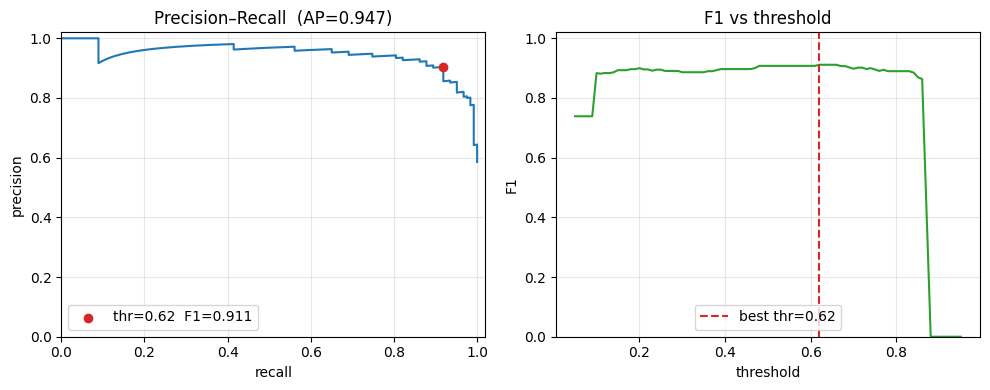

best threshold : 0.620   val F1 = 0.9113
vs 0.5 default :              val F1 = 0.9076  (Δ +0.0037)
✅ threshold + PR curve saved


In [28]:
#0503

from smart_turn import evaluate_and_save_threshold

threshold_payload = evaluate_and_save_threshold(trainer, eval_dataset, CHECKPOINT_DIR)
print("✅ threshold + PR curve saved")

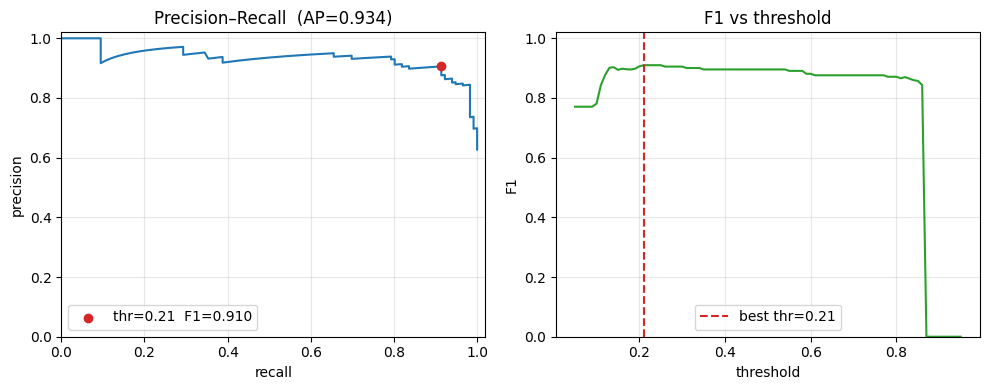

best threshold : 0.210   val F1 = 0.9099
vs 0.5 default :              val F1 = 0.8957  (Δ +0.0142)
✅ threshold + PR curve saved


In [20]:
from smart_turn import evaluate_and_save_threshold

threshold_payload = evaluate_and_save_threshold(trainer, eval_dataset, CHECKPOINT_DIR)
print("✅ threshold + PR curve saved")

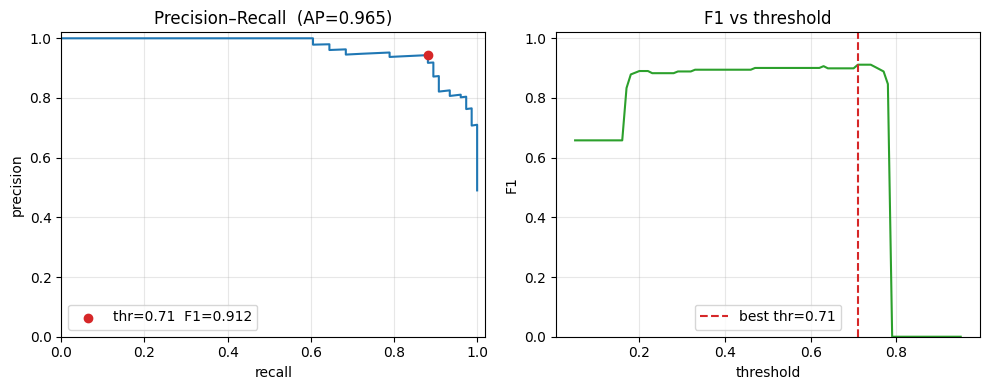

best threshold : 0.710   val F1 = 0.9116
vs 0.5 default :              val F1 = 0.9007  (Δ +0.0109)
✅ threshold + PR curve saved


In [9]:
from smart_turn import evaluate_and_save_threshold

threshold_payload = evaluate_and_save_threshold(trainer, eval_dataset, CHECKPOINT_DIR)
print("✅ threshold + PR curve saved")

## Save

`03_compare.ipynb` and `04_export.ipynb` both reload from this path
with `SmartTurnModel.from_pretrained`. The feature extractor goes
alongside so inference doesn't have to re-derive the mel config.

In [29]:
model.save_pretrained(CHECKPOINT_DIR)
feature_extractor.save_pretrained(CHECKPOINT_DIR)
rel = CHECKPOINT_DIR.relative_to(CHECKPOINT_DIR.parent.parent)
print("saved :", rel)
print("files :", sorted(p.name for p in CHECKPOINT_DIR.iterdir() if p.is_file()))
print("✅ checkpoint saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved : smart-turn-zh-0503/specaugment
files : ['config.json', 'model.safetensors', 'preprocessor_config.json', 'threshold.json']
✅ checkpoint saved


## Next

Once you've also run the other `02_<letter>_*` variants you want to
compare:

- `03_compare.ipynb` reloads every variant's checkpoint, scores them
  on `ds["test"]` at each one's shipped threshold, and emits a
  side-by-side metrics table + overlaid PR curves so you can pick a
  winner.
- `04_export.ipynb` then takes that single winner and produces FP32 +
  INT8 ONNX artifacts and a CPU latency benchmark.